In [34]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import Dropout

from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

In [35]:
base_path = "/kaggle/input/fruit-freshness-dataset-v1/dataset"

In [36]:
import os

for root, dirs, files in os.walk("/kaggle/input"):
    print(root)

/kaggle/input
/kaggle/input/datasets
/kaggle/input/datasets/user2036
/kaggle/input/datasets/user2036/fruit-freshness-dataset-v1
/kaggle/input/datasets/user2036/fruit-freshness-dataset-v1/test
/kaggle/input/datasets/user2036/fruit-freshness-dataset-v1/test/rottenbanana
/kaggle/input/datasets/user2036/fruit-freshness-dataset-v1/test/orange
/kaggle/input/datasets/user2036/fruit-freshness-dataset-v1/test/apple
/kaggle/input/datasets/user2036/fruit-freshness-dataset-v1/test/rottenoranges
/kaggle/input/datasets/user2036/fruit-freshness-dataset-v1/test/rottenapples
/kaggle/input/datasets/user2036/fruit-freshness-dataset-v1/test/banana
/kaggle/input/datasets/user2036/fruit-freshness-dataset-v1/train
/kaggle/input/datasets/user2036/fruit-freshness-dataset-v1/train/rottenbanana
/kaggle/input/datasets/user2036/fruit-freshness-dataset-v1/train/orange
/kaggle/input/datasets/user2036/fruit-freshness-dataset-v1/train/apple
/kaggle/input/datasets/user2036/fruit-freshness-dataset-v1/train/rottenoranges

In [37]:
train_dir = "/kaggle/input/datasets/user2036/fruit-freshness-dataset-v1/train"
test_dir = "/kaggle/input/datasets/user2036/fruit-freshness-dataset-v1/test"

import os

print("Training Classes:")
print(os.listdir(train_dir))

print("\nTesting Classes:")
print(os.listdir(test_dir))

Training Classes:
['rottenbanana', 'orange', 'apple', 'rottenoranges', 'rottenapples', 'banana']

Testing Classes:
['rottenbanana', 'orange', 'apple', 'rottenoranges', 'rottenapples', 'banana']


In [38]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, Dense, Dropout

In [39]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True,
    validation_split=0.2
)

test_datagen = ImageDataGenerator(
    rescale=1./255
)

In [40]:
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training'
)

Found 7566 images belonging to 6 classes.


In [41]:
validation_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation'
)

Found 1887 images belonging to 6 classes.


In [42]:
test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

Found 1879 images belonging to 6 classes.


In [43]:
print(train_generator.class_indices)

{'apple': 0, 'banana': 1, 'orange': 2, 'rottenapples': 3, 'rottenbanana': 4, 'rottenoranges': 5}


In [44]:
cnn_model = Sequential([
    
    Conv2D(32, (3,3), activation='relu',
           input_shape=(224,224,3)),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),

    Dense(128, activation='relu'),
    Dropout(0.5),

    Dense(6, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [45]:
cnn_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

cnn_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,734 (42.61 MB)

 Trainable params: 11,169,734 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [46]:
history = cnn_model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=10
)

Epoch 1/10
237/237 ━━━━━━━━━━━━━━━━━━━━ 132s 544ms/step - accuracy: 0.6647 - loss: 0.9136 - val_accuracy: 0.7944 - val_loss: 0.5522
Epoch 2/10
237/237 ━━━━━━━━━━━━━━━━━━━━ 122s 513ms/step - accuracy: 0.8002 - loss: 0.5676 - val_accuracy: 0.8781 - val_loss: 0.3544
Epoch 3/10
237/237 ━━━━━━━━━━━━━━━━━━━━ 121s 513ms/step - accuracy: 0.8292 - loss: 0.4833 - val_accuracy: 0.9062 - val_loss: 0.2871
Epoch 4/10
237/237 ━━━━━━━━━━━━━━━━━━━━ 121s 510ms/step - accuracy: 0.8541 - loss: 0.4041 - val_accuracy: 0.9184 - val_loss: 0.2457
Epoch 5/10
237/237 ━━━━━━━━━━━━━━━━━━━━ 122s 514ms/step - accuracy: 0.8645 - loss: 0.3890 - val_accuracy: 0.9184 - val_loss: 0.2270
Epoch 6/10
237/237 ━━━━━━━━━━━━━━━━━━━━ 122s 514ms/step - accuracy: 0.8777 - loss: 0.3357 - val_accuracy: 0.9274 - val_loss: 0.1829
Epoch 7/10
237/237 ━━━━━━━━━━━━━━━━━━━━ 128s 543ms/step - accuracy: 0.8882 - loss: 0.3251 - val_accuracy: 0.9295 - val_loss: 0.1936
Epoch 8/10
237/237 ━━━━━━━━━━━━━━━━━━━━ 130s 550ms/step - accuracy: 0.9048 -

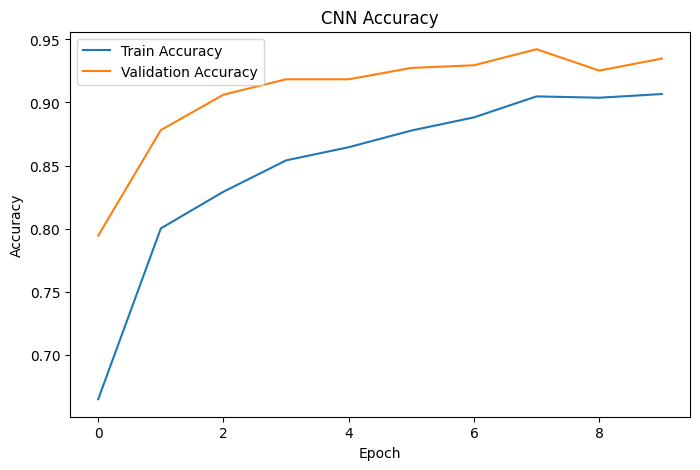

In [47]:
plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("CNN Accuracy")
plt.legend()

plt.show()

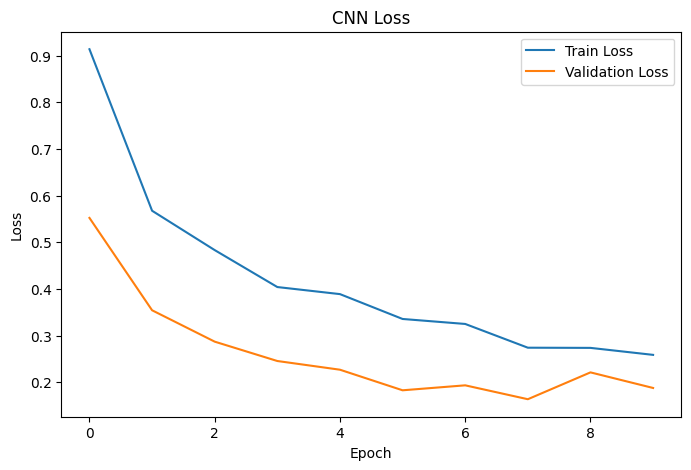

In [48]:
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("CNN Loss")
plt.legend()

plt.show()

In [49]:
test_loss, test_accuracy = cnn_model.evaluate(test_generator)

print("Test Accuracy:", test_accuracy)
print("Test Loss:", test_loss)

59/59 ━━━━━━━━━━━━━━━━━━━━ 12s 197ms/step - accuracy: 0.9250 - loss: 0.2166
Test Accuracy: 0.9249600768089294
Test Loss: 0.21661724150180817


59/59 ━━━━━━━━━━━━━━━━━━━━ 9s 139ms/step


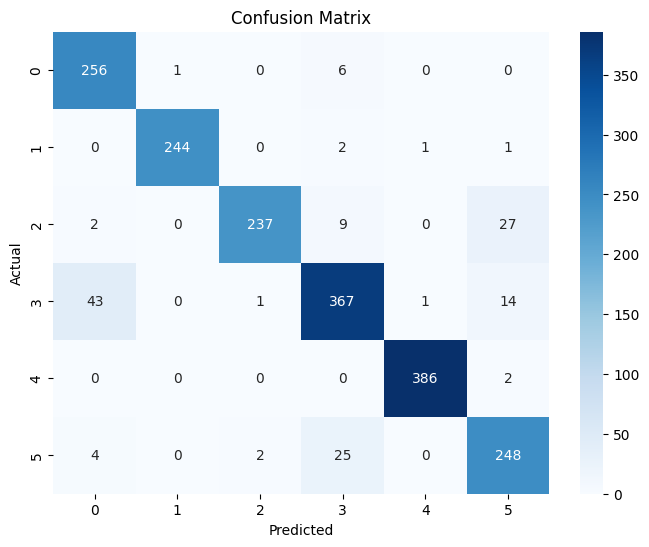

In [50]:
import numpy as np
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

test_generator.reset()

y_pred = cnn_model.predict(test_generator)
y_pred_classes = np.argmax(y_pred, axis=1)

y_true = test_generator.classes

cm = confusion_matrix(y_true, y_pred_classes)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [51]:
from sklearn.metrics import classification_report

print(classification_report(y_true, y_pred_classes))

              precision    recall  f1-score   support

           0       0.84      0.97      0.90       263
           1       1.00      0.98      0.99       248
           2       0.99      0.86      0.92       275
           3       0.90      0.86      0.88       426
           4       0.99      0.99      0.99       388
           5       0.85      0.89      0.87       279

    accuracy                           0.92      1879
   macro avg       0.93      0.93      0.93      1879
weighted avg       0.93      0.92      0.93      1879



In [52]:
cnn_model.save("cnn_final_model.keras")

print("Model saved successfully!")

Model saved successfully!


In [53]:
print("="*50)
print("FINAL CNN MODEL RESULTS")
print("="*50)

print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test Loss: {test_loss:.4f}")

print("="*50)

FINAL CNN MODEL RESULTS
Test Accuracy: 0.9250
Test Loss: 0.2166


In [54]:
from sklearn.metrics import classification_report

report = classification_report(y_true, y_pred_classes)

with open("classification_report.txt", "w") as f:
    f.write(report)

print(report)

              precision    recall  f1-score   support

           0       0.84      0.97      0.90       263
           1       1.00      0.98      0.99       248
           2       0.99      0.86      0.92       275
           3       0.90      0.86      0.88       426
           4       0.99      0.99      0.99       388
           5       0.85      0.89      0.87       279

    accuracy                           0.92      1879
   macro avg       0.93      0.93      0.93      1879
weighted avg       0.93      0.92      0.93      1879



In [55]:
from tensorflow.keras.preprocessing import image
import numpy as np

class_names = list(test_generator.class_indices.keys())

def predict_image(img_path):
    img = image.load_img(img_path, target_size=(224,224))
    img = image.img_to_array(img)
    img = np.expand_dims(img, axis=0)
    img = img / 255.0

    prediction = cnn_model.predict(img)

    predicted_class = np.argmax(prediction)

    print("Predicted Class:", class_names[predicted_class])

    return class_names[predicted_class]

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing import image
import os

# Load your trained model
model = tf.keras.models.load_model("model.h5")

# Class labels (change according to your dataset)
class_names = ["Fresh", "Rotten"]

FileNotFoundError: [Errno 2] Unable to synchronously open file (unable to open file: name = 'model.h5', errno = 2, error message = 'No such file or directory', flags = 0, o_flags = 0)

In [56]:
print("""
PROJECT SUMMARY
----------------------------------------
Model Used      : Convolutional Neural Network (CNN)
Evaluation      : Test Dataset
Metrics Used    : Accuracy, Loss, Precision, Recall, F1-Score

Final Results
----------------------------------------
""")

print(f"Test Accuracy : {test_accuracy:.2%}")
print(f"Test Loss     : {test_loss:.4f}")


PROJECT SUMMARY
----------------------------------------
Model Used      : Convolutional Neural Network (CNN)
Evaluation      : Test Dataset
Metrics Used    : Accuracy, Loss, Precision, Recall, F1-Score

Final Results
----------------------------------------

Test Accuracy : 92.50%
Test Loss     : 0.2166


In [10]:
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames[:5]:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/sriramr/fruits-fresh-and-rotten-for-classification/dataset/dataset/test/rottenbanana/saltandpepper_Screen Shot 2018-06-12 at 8.53.54 PM.png
/kaggle/input/datasets/sriramr/fruits-fresh-and-rotten-for-classification/dataset/dataset/test/rottenbanana/Screen Shot 2018-06-12 at 9.27.26 PM.png
/kaggle/input/datasets/sriramr/fruits-fresh-and-rotten-for-classification/dataset/dataset/test/rottenbanana/rotated_by_45_Screen Shot 2018-06-12 at 8.58.13 PM.png
/kaggle/input/datasets/sriramr/fruits-fresh-and-rotten-for-classification/dataset/dataset/test/rottenbanana/rotated_by_75_Screen Shot 2018-06-12 at 8.47.41 PM.png
/kaggle/input/datasets/sriramr/fruits-fresh-and-rotten-for-classification/dataset/dataset/test/rottenbanana/rotated_by_75_Screen Shot 2018-06-12 at 8.56.30 PM.png
/kaggle/input/datasets/sriramr/fruits-fresh-and-rotten-for-classification/dataset/dataset/test/freshoranges/rotated_by_15_Screen Shot 2018-06-13 at 12.01.03 AM.png
/kaggle/input/datasets/sriramr/frui

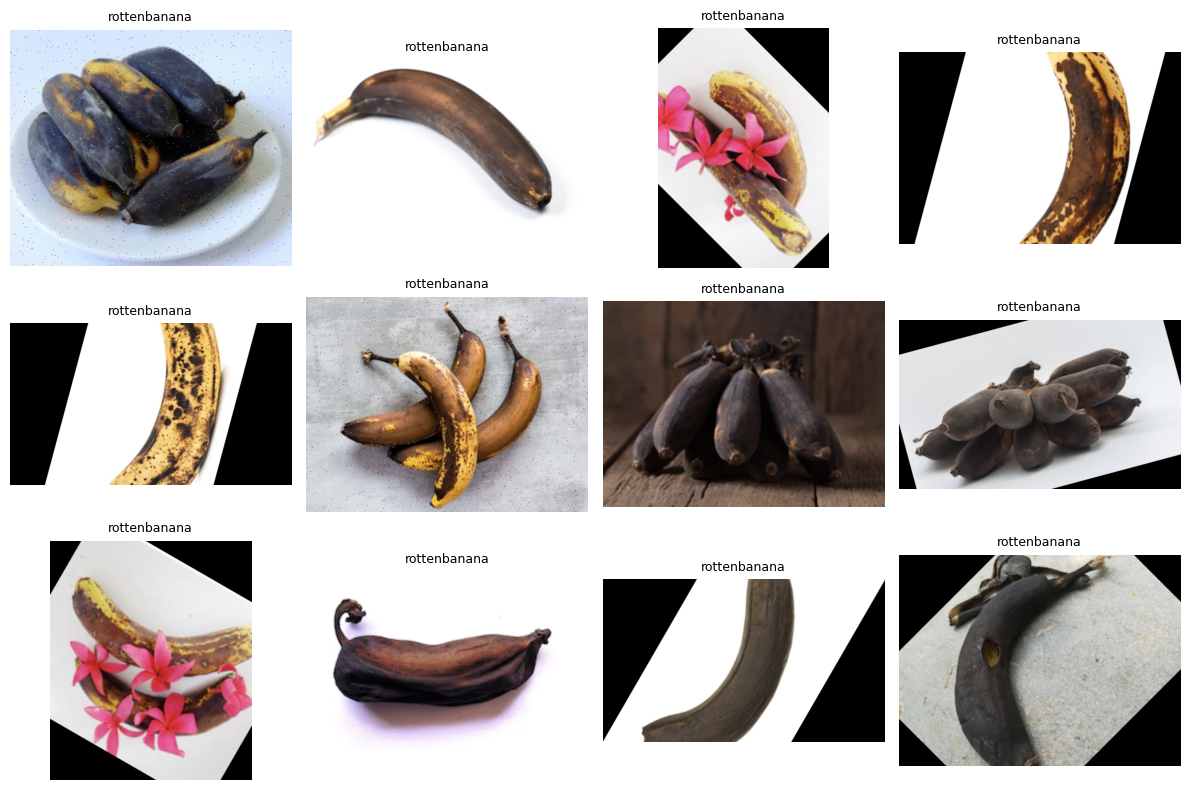

In [15]:
import os
import matplotlib.pyplot as plt
from PIL import Image

test_folder = "/kaggle/input/datasets/sriramr/fruits-fresh-and-rotten-for-classification/dataset/test/"

images = []
labels = []

# collect images
for root, dirs, files in os.walk(test_folder):
    for file in files[:12]:   # take 12 images
        img_path = os.path.join(root, file)
        img = Image.open(img_path)

        images.append(img)
        labels.append(root.split("/")[-1])

    if len(images) >= 12:
        break

# plot grid
plt.figure(figsize=(12, 8))

for i in range(len(images)):
    plt.subplot(3, 4, i + 1)
    plt.imshow(images[i])
    plt.title(labels[i], fontsize=9)
    plt.axis("off")

plt.tight_layout()
plt.show()